In [1]:
from scripts.process_log_folder import *
from scripts.quaternions_utilities import *
from scripts import visualizations
from scripts import statistics
from scripts.process_eye_quaternions import *
from importlib import reload
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

See https://docs.google.com/document/d/1_gHBGldGqvFioNrJ2AenYv8mXAnb3xhIrwBUUMM7wck/edit?usp=sharing or README.md for more details.

## Load trials data

In [2]:
from pathlib import Path

# Define a folder and a file
folder_path = Path("../Logs")

In [3]:
df_step, df_eyetrack = process_log_folder(folder_path)

Processing participants: 100%|█████████████████████████████████████████████████████████| 20/20 [00:11<00:00,  1.70it/s]


# Gaze Tracking

### Preprocessing

In [4]:
# Get eye yaw and pitch (in degrees)
df_eyetrack = add_eye_yaw_pitch(df_eyetrack)

# group by trial and add time since trial start
df_eyetrack = df_eyetrack.sort_values(by=['trial', 'timeSinceStartup'])
df_eyetrack['timeSinceTrialStart'] = df_eyetrack.groupby('trial')['timeSinceStartup'].transform(lambda x: x - x.min())

# Drop rows where all specified columns are NaN
df_eyetrack_preprocessed = df_eyetrack.dropna(
    subset=['condition', 'position', 'lateralisation', 'nb_dist'],
    how='all'
)

# get rid of trials with 50% of missing data in eye tracking
def clean_eye_yaw(df, tol=0.9, eye ="Right"):
    """
    Cleans the trial data if eye yaw value is 0 for more than 90% of the time.
    """
    cleaned_df = df.copy()
    trials = cleaned_df['trial'].unique()

    trials_cleaned = 0

    for trial in trials:
        trial_data = cleaned_df[cleaned_df['trial'] == trial]
        total_frames = len(trial_data)
        if eye == "Right":
            zero_frames = (trial_data['rEyeYaw'] == 0).sum()
        else:
            zero_frames = (trial_data['lEyeYaw'] == 0).sum()

        if total_frames > 0 and (zero_frames / total_frames) > tol:
            # Set eye_yaw to NaN for this trial
            if eye == "Right":
                cleaned_df.loc[cleaned_df['trial'] == trial, 'rEyeYaw'] = np.nan
            else:
                cleaned_df.loc[cleaned_df['trial'] == trial, 'lEyeYaw'] = np.nan
            trials_cleaned += 1

    cleaned_df = cleaned_df.dropna()
        
    print(f"Cleaned {trials_cleaned} trials out of {len(trials)} ({(trials_cleaned/len(trials))*100:.2f}%) due to excessive zero eye_yaw values.")  

    return cleaned_df
df_eyetrack_preprocessed = clean_eye_yaw(df_eyetrack_preprocessed, tol=0.5)

# Remove incorrect trials
nb_trials_before = len(df_eyetrack_preprocessed['trial'].unique())
df_eyetrack_preprocessed = df_eyetrack_preprocessed[df_eyetrack_preprocessed['correct']==True]
nb_trials_after = len(df_eyetrack_preprocessed['trial'].unique())
print(f"Trials removed because incorrect trials were removed = {nb_trials_before-nb_trials_after} trials")

# Remove participant 24 (lots of 0 values)
nb_trials_before = len(df_eyetrack_preprocessed['trial'].unique())
df_eyetrack_preprocessed = df_eyetrack_preprocessed[~(df_eyetrack_preprocessed['participant']=='24')]
nb_trials_after = len(df_eyetrack_preprocessed['trial'].unique())
print(f"Trials removed because participant 24 was removed = {nb_trials_before-nb_trials_after} trials")

# Unwrap each trial so that if one looks complety 180° and mopre it doesnt wrap over and continue in the 180+°
for col in ["lEyeYaw", "rEyeYaw", "lEyePitch", "rEyePitch"]:
    df_eyetrack_preprocessed[f"{col}"] = (
        df_eyetrack_preprocessed.groupby("trial")[col]
        .transform(lambda y: np.unwrap(y.to_numpy(), discont=180, period=360))
    )

# Merge left and right
df_eyetrack_preprocessed_merged = df_eyetrack_preprocessed.copy()
df_eyetrack_preprocessed_merged.loc[df_eyetrack_preprocessed_merged['lateralisation']=="Left",['rEyeYaw','lEyeYaw']] *= -1

Cleaned 88 trials out of 3075 (2.86%) due to excessive zero eye_yaw values.
Trials removed because incorrect trials were removed = 74 trials
Trials removed because participant 24 was removed = 129 trials


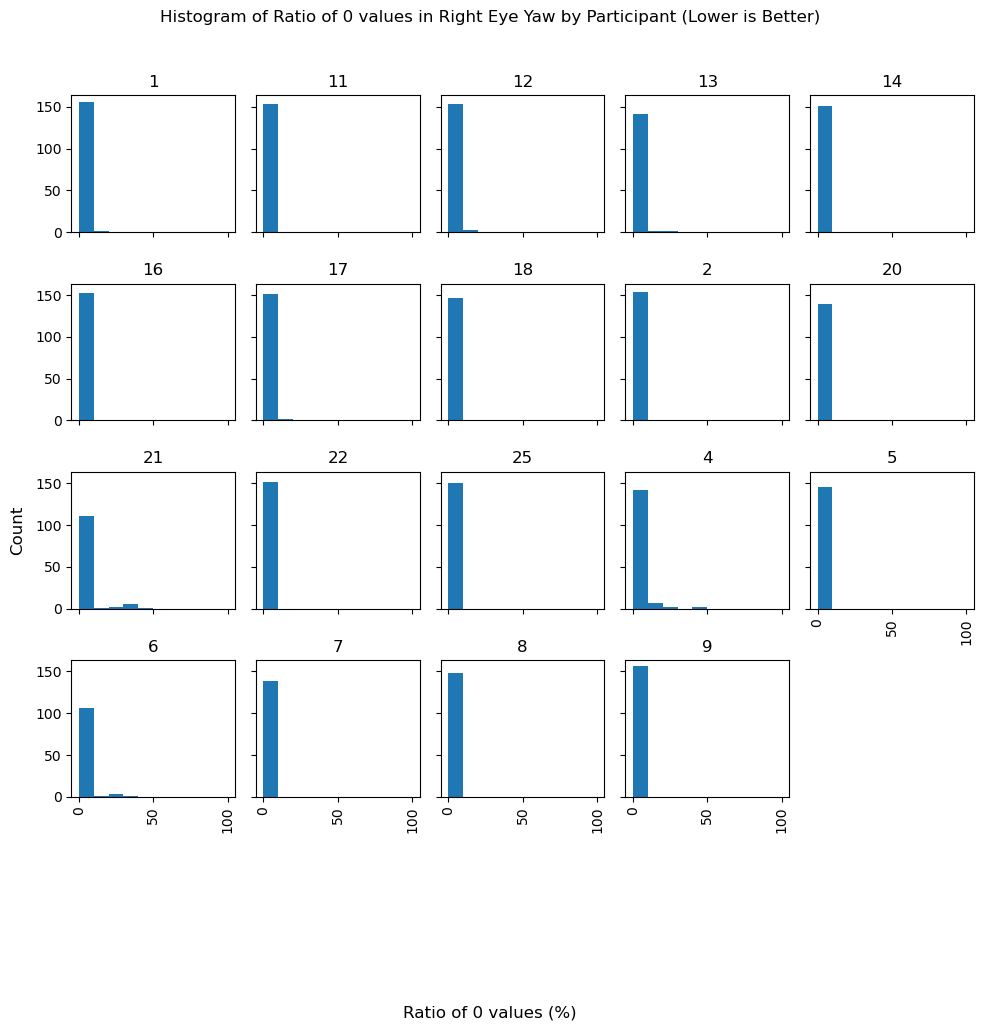

In [5]:
# participants with high ratio of 0 values in eye tracking

# group by participant and trial, aggregate rEyeYaw into a list
df_participants = df_eyetrack_preprocessed.groupby(['participant','trial'])['rEyeYaw'].apply(list).reset_index()

# compute ratio of 0 values in rEyeYaw for each participant
df_participants['ratio_zero_values'] = df_participants['rEyeYaw'].apply(lambda x: (np.array(x)==0).sum()/len(x)*100 if len(x)>0 else np.nan)

#plot histogram of ratio of 0 values by participant
df_participants.hist('ratio_zero_values', bins=10,by='participant', layout=(5,5), figsize=(10,10), sharex=True, sharey=True, range=(0,100))


plt.suptitle('Histogram of Ratio of 0 values in Right Eye Yaw by Participant (Lower is Better)', y=1.02)
plt.gcf().supxlabel("Ratio of 0 values (%)")
plt.gcf().supylabel("Count")
plt.tight_layout()
plt.savefig("fig/hostZeroValues_tol05.png", bbox_inches='tight')
plt.show()


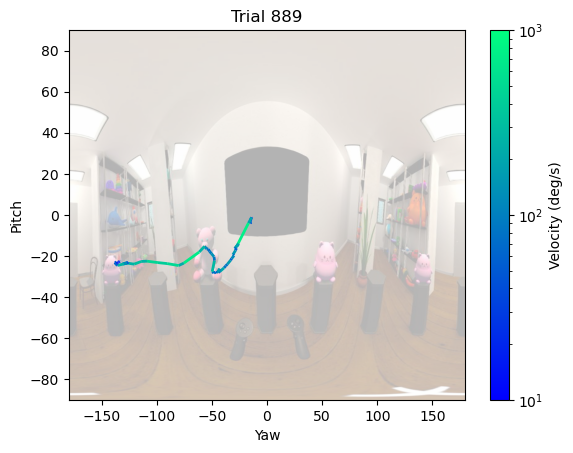

<Figure size 640x480 with 0 Axes>

In [6]:
# exploratory
reload(visualizations)

visualizations.plot_eye_displacement_per_trial(df_eyetrack_preprocessed, 889)
plt.savefig('fig/overlay.png')

### Heatmap

#### Real data Heatmap

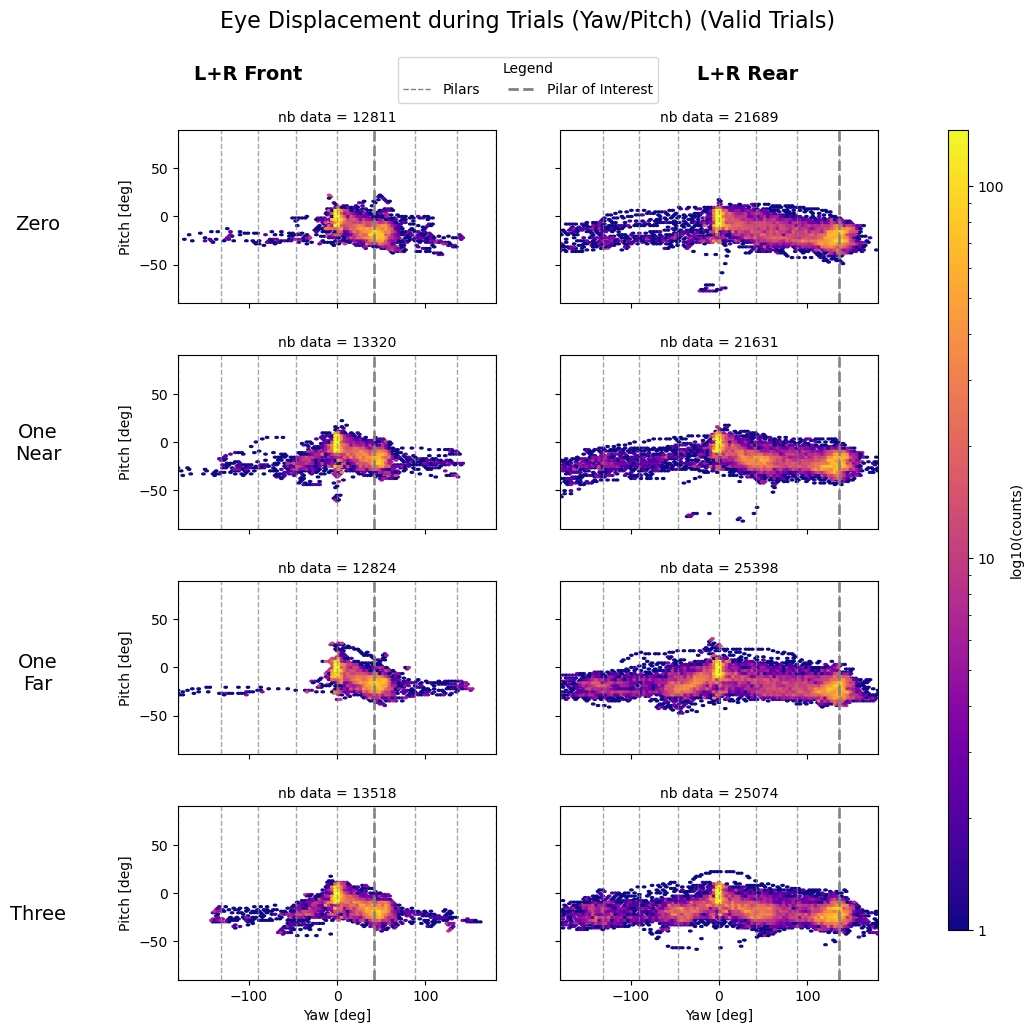

In [7]:
# heatmap of eye positions during trials
reload(visualizations)
fig, axes, mapping = visualizations.plot_eye_displacement_by_distractors(
    df_eyetrack_preprocessed,
    eye="Right",
    condition=("Valid"),
    log_scale=50,
    show=True,
    merge_left_right=True,
    gridsize_hex=100,
    savepath='fig/heatmap.svg'
)

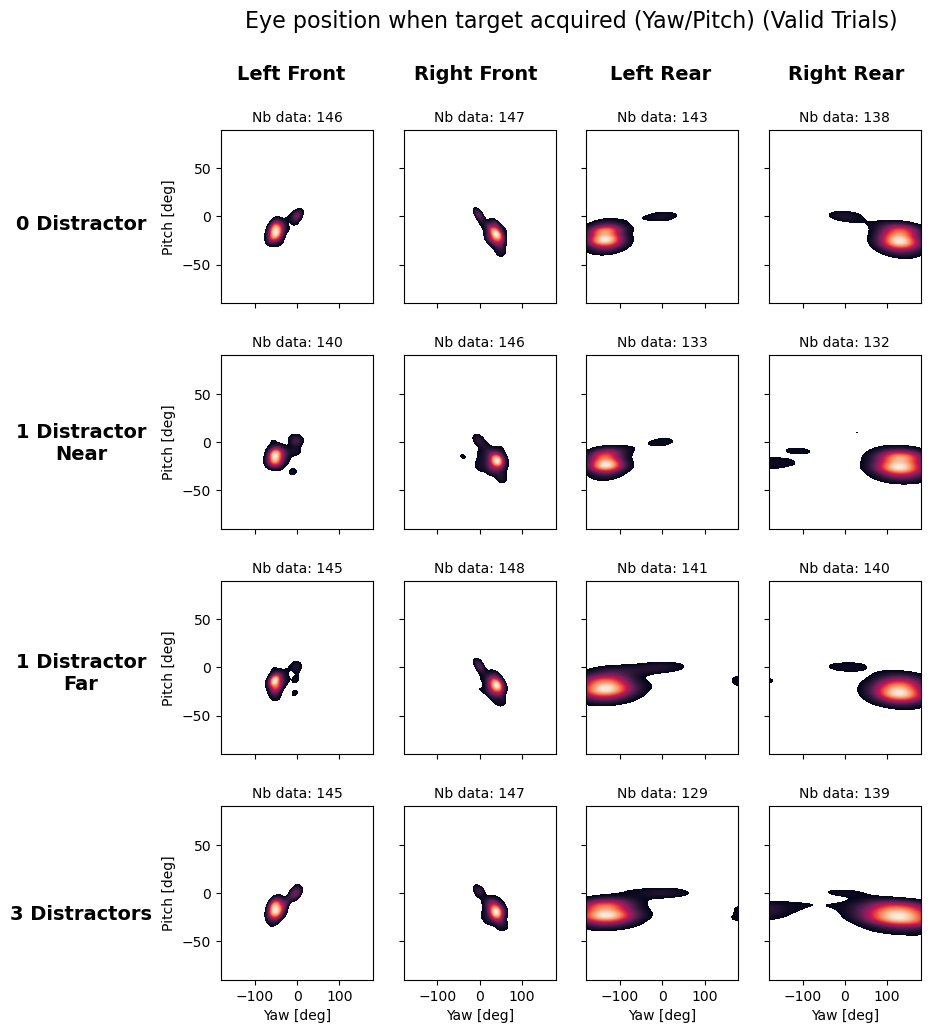

In [8]:
# custom KDE look
reload(visualizations)
fig, axes, mapping, df_target = visualizations.plot_eye_at_trial_end(
    df_eyetrack_preprocessed, df_step,
    mode="kde",
    kde_levels=80,
    kde_thresh=0.1,
    savepath="fig/eyePositionEndTimeKDE.png"
)

C:\Users\deschane\AppData\Local\Temp\ipykernel_18880\1463320583.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


Figure saved successfully!


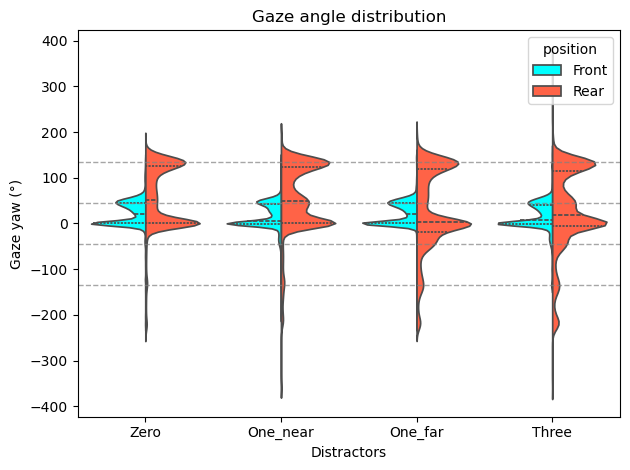

In [9]:
# Violin plot

import seaborn as sns
import matplotlib.pyplot as plt

plt.close('all')
df_valid = df_eyetrack_preprocessed_merged[df_eyetrack_preprocessed_merged['condition'] == 'Valid']

sns.violinplot(
    data=df_valid,
    #x='rEyeYaw',   
    #y='nb_dist',            # each distractor level stacked vertically
    
    x = 'nb_dist',
    y = 'rEyeYaw',  # each distractor level stacked horizontally

    order=['Zero','One_near','One_far','Three'],  # order of distractor levels
    hue='position',         # split by position (Front/Rear)
    hue_order=['Front', 'Rear'],
    split=True,             # half-violins side by side
    #orient='h',             # <--- makes the plot horizontal
    inner='quart',
    scale='width',          # keeps widths comparable across categories
    palette=['aqua', 'tomato'],
    saturation=1.0  # Full saturation
)

# --- Add vertical reference lines for pillar angles
pilars_angle = [45, 135, -135, -45]

# basic gray dashed lines for all pilars
#for angle in pilars_angle:
#    plt.axvline(x=angle, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# basic gray dashed lines for all pilars (now horizontal)
for angle in pilars_angle:
    plt.axhline(y=angle, color='gray', linestyle='--', linewidth=1, alpha=0.7)

#sns.set_style("white")
plt.title("Gaze angle distribution")
#plt.xlabel("Gaze yaw (°)")
#plt.ylabel("Number of distractors")
plt.xlabel("Distractors")
plt.ylabel("Gaze yaw (°)")

plt.tight_layout()
# Save the figure
plt.savefig("fig/eyeDisplacement_violin_vertical.svg", 
            bbox_inches='tight',
            dpi=300,
            facecolor='white')  # Explicitly set background

print("Figure saved successfully!")
plt.show()


##### Cluster dwell time around pilars

In [10]:
#mannwhitney U tests on eyetracking distribution on distractor

# For Front position
df_front = df_eyetrack_preprocessed_merged[
    df_eyetrack_preprocessed_merged["position"] == "Front"
]

# Create groups for valid vs invalid comparisons for each distractor type
front_groups = {
    # Zero distractors
    "Valid_Zero": df_front[(df_front["nb_dist"] == "Zero") & (df_front["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_Zero": df_front[(df_front["nb_dist"] == "Zero") & (df_front["condition"] == "Invalid")]["rEyeYaw"],
    
    # One_near distractors
    "Valid_One_near": df_front[(df_front["nb_dist"] == "One_near") & (df_front["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_One_near": df_front[(df_front["nb_dist"] == "One_near") & (df_front["condition"] == "Invalid")]["rEyeYaw"],
    
    # One_far distractors
    "Valid_One_far": df_front[(df_front["nb_dist"] == "One_far") & (df_front["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_One_far": df_front[(df_front["nb_dist"] == "One_far") & (df_front["condition"] == "Invalid")]["rEyeYaw"],
    
    # Three distractors
    "Valid_Three": df_front[(df_front["nb_dist"] == "Three") & (df_front["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_Three": df_front[(df_front["nb_dist"] == "Three") & (df_front["condition"] == "Invalid")]["rEyeYaw"]
}

# For Rear position
df_rear = df_eyetrack_preprocessed_merged[
    df_eyetrack_preprocessed_merged["position"] == "Rear"
]

rear_groups = {
    # Zero distractors
    "Valid_Zero": df_rear[(df_rear["nb_dist"] == "Zero") & (df_rear["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_Zero": df_rear[(df_rear["nb_dist"] == "Zero") & (df_rear["condition"] == "Invalid")]["rEyeYaw"],
    
    # One_near distractors
    "Valid_One_near": df_rear[(df_rear["nb_dist"] == "One_near") & (df_rear["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_One_near": df_rear[(df_rear["nb_dist"] == "One_near") & (df_rear["condition"] == "Invalid")]["rEyeYaw"],
    
    # One_far distractors
    "Valid_One_far": df_rear[(df_rear["nb_dist"] == "One_far") & (df_rear["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_One_far": df_rear[(df_rear["nb_dist"] == "One_far") & (df_rear["condition"] == "Invalid")]["rEyeYaw"],
    
    # Three distractors
    "Valid_Three": df_rear[(df_rear["nb_dist"] == "Three") & (df_rear["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_Three": df_rear[(df_rear["nb_dist"] == "Three") & (df_rear["condition"] == "Invalid")]["rEyeYaw"]
}

def mannwhitney_table(groups, comparisons):
    """
    groups: dict of {group_name: pd.Series}
    comparisons: list of tuples of group names to compare
    returns: pandas DataFrame in APA-style format
    """
    rows = []
    for g1, g2 in comparisons:
        data1 = groups[g1]
        data2 = groups[g2]
        
        stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
        
        # Sample sizes
        n1 = len(data1)
        n2 = len(data2)

        # Calculate z for effect size r
        mean_U = n1*n2/2
        std_U = np.sqrt(n1*n2*(n1+n2+1)/12)
        z = (stat - mean_U) / std_U

        r = abs(z) / np.sqrt(n1 + n2)

        rows.append({
            "Comparison": f"{g1} vs {g2}",
            "n1": n1,
            "n2": n2,
            f"{g1} median": data1.median(),
            f"{g2} median": data2.median(),
            "U": stat,
            "z": round(z, 2),
            "p": round(p, 3),
            "r": round(r, 2)
        })
        
    return pd.DataFrame(rows)
# Define comparisons for valid vs invalid for each distractor type
comparisons_valid_invalid = [
    ("Valid_Zero", "Invalid_Zero"),
    ("Valid_One_near", "Invalid_One_near"),
    ("Valid_One_far", "Invalid_One_far"),
    ("Valid_Three", "Invalid_Three")
]

# Generate tables using your existing function
table_front_valid_invalid = mannwhitney_table(front_groups, comparisons_valid_invalid)
table_rear_valid_invalid = mannwhitney_table(rear_groups, comparisons_valid_invalid)

print("Front position - Valid vs Invalid comparisons:\n", table_front_valid_invalid)
print("\nRear position - Valid vs Invalid comparisons:\n", table_rear_valid_invalid)

# If you also want to compare between distractor types within validity conditions,
# you can create additional comparisons:
comparisons_within_valid = [
    ("Valid_Zero", "Valid_One_near"),
    ("Valid_Zero", "Valid_One_far"),
    ("Valid_Zero", "Valid_Three"),
    ("Valid_One_near", "Valid_One_far"),
    ("Valid_One_near", "Valid_Three"),
    ("Valid_One_far", "Valid_Three")
]

comparisons_within_invalid = [
    ("Invalid_Zero", "Invalid_One_near"),
    ("Invalid_Zero", "Invalid_One_far"),
    ("Invalid_Zero", "Invalid_Three"),
    ("Invalid_One_near", "Invalid_One_far"),
    ("Invalid_One_near", "Invalid_Three"),
    ("Invalid_One_far", "Invalid_Three")
]

print("\nFront - Within Valid condition:\n", mannwhitney_table(front_groups, comparisons_within_valid))
print("\nFront - Within Invalid condition:\n", mannwhitney_table(front_groups, comparisons_within_invalid))
print("\nRear - Within Valid condition:\n", mannwhitney_table(rear_groups, comparisons_within_valid))
print("\nRear - Within Invalid condition:\n", mannwhitney_table(rear_groups, comparisons_within_invalid))

Front position - Valid vs Invalid comparisons:
                            Comparison     n1    n2  Valid_Zero median  \
0          Valid_Zero vs Invalid_Zero  12811  3611          21.453514   
1  Valid_One_near vs Invalid_One_near  13320  3639                NaN   
2    Valid_One_far vs Invalid_One_far  12824  3437                NaN   
3        Valid_Three vs Invalid_Three  13518  3475                NaN   

   Invalid_Zero median           U      z    p     r  Valid_One_near median  \
0             9.336695  25954220.5  11.22  0.0  0.09                    NaN   
1                  NaN  26980502.0  10.49  0.0  0.08               6.041393   
2                  NaN  23424367.0   5.67  0.0  0.04                    NaN   
3                  NaN  25906056.0   9.38  0.0  0.07                    NaN   

   Invalid_One_near median  Valid_One_far median  Invalid_One_far median  \
0                      NaN                   NaN                     NaN   
1                 2.125255            

In [11]:
# For Front position
df_front = df_eyetrack_preprocessed_merged[
    df_eyetrack_preprocessed_merged["position"] == "Front"
]

# Create groups for valid vs invalid comparisons for FRONT only
front_groups = {
    "Valid_f": df_front[(df_front["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_f": df_front[(df_front["condition"] == "Invalid")]["rEyeYaw"],
}

# For Rear position
df_rear = df_eyetrack_preprocessed_merged[
    df_eyetrack_preprocessed_merged["position"] == "Rear"
]

# Create groups for valid vs invalid comparisons for REAR only
rear_groups = {
    "Valid_r": df_rear[(df_rear["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_r": df_rear[(df_rear["condition"] == "Invalid")]["rEyeYaw"],
}

# Define comparisons - SEPARATE for front and rear
comparisons_front = [
    ("Valid_f", "Invalid_f")
]

comparisons_rear = [
    ("Valid_r", "Invalid_r")
]

# Generate tables using your existing function
table_front_cue = mannwhitney_table(front_groups, comparisons_front)
table_rear_cue = mannwhitney_table(rear_groups, comparisons_rear)

print("Front position - Valid vs Invalid cue:\n", table_front_cue)
print("\nRear position - Valid vs Invalid cue:\n", table_rear_cue)

Front position - Valid vs Invalid cue:
              Comparison     n1     n2  Valid_f median  Invalid_f median  \
0  Valid_f vs Invalid_f  52473  14162       12.620505          4.833093   

             U      z    p     r  
0  408582863.0  18.22  0.0  0.07  

Rear position - Valid vs Invalid cue:
              Comparison     n1     n2  Valid_r median  Invalid_r median  \
0  Valid_r vs Invalid_r  93792  27154       33.534732         -2.111052   

              U      z    p     r  
0  1.677752e+09  79.81  0.0  0.23  


In [12]:
reload(statistics)

ANGLE_ROI = 5

# Compute dwell time for the whole dataset
df_dwell = (
    df_eyetrack_preprocessed_merged
    .groupby('trial')
    .apply(statistics.compute_dwell_time_per_trial, angle_roi=ANGLE_ROI)
    .reset_index()
)

# Enrich dwell df with metadata
cols_meta = ['trial', 'participant', 'position', 'lateralisation', 'nb_dist', 'condition']
df_trials = df_eyetrack_preprocessed[cols_meta].drop_duplicates().merge(df_dwell, on='trial', how='left')

C:\Users\deschane\AppData\Local\Temp\ipykernel_18880\4162358287.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(statistics.compute_dwell_time_per_trial, angle_roi=ANGLE_ROI)


TypeError: Axes.boxplot() got an unexpected keyword argument 'tick_labels'

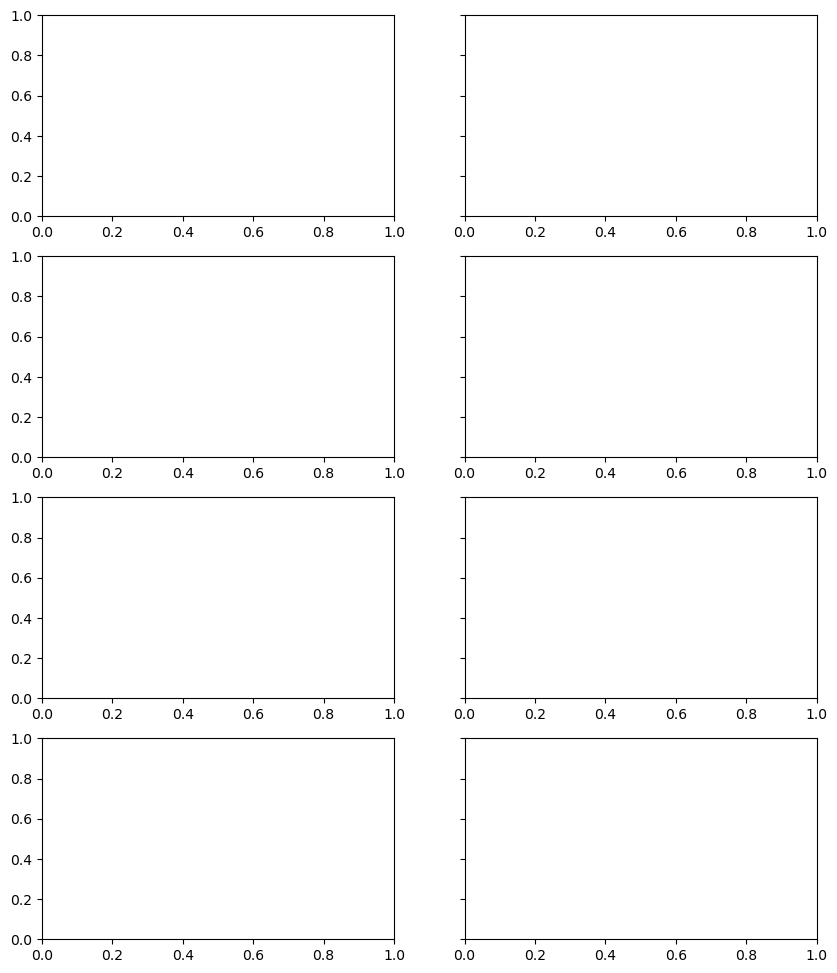

In [13]:
# Explore Dwell time
reload(visualizations)

visualizations.plot_dwell_time(df_trials[df_trials['condition']=='Invalid'],angle_roi=ANGLE_ROI)


##### response time vs object time

In [ ]:
from scripts import statistics
reload(statistics)

# Compute object time for the whole dataset
df_object = (
    df_eyetrack_preprocessed_merged
    .groupby('trial')
    .apply(statistics.get_object_time)
    .reset_index()
)

# Enrich dwell df with metadata
cols_meta = ['trial', 'participant', 'position', 'lateralisation', 'nb_dist']
df_trials = df_eyetrack_preprocessed[cols_meta].drop_duplicates().merge(df_object, on='trial', how='left')

positions = df_trials.position.unique()
sides = df_trials.lateralisation.unique()

# How where there is no object times and in each case
for position in positions:
    for side in sides:
        df = df_trials[
            (df_trials['position'] == position) &
            (df_trials['lateralisation'] == side)
        ]
        missings = np.sum(np.isnan(df['object_time']))
        total = len(df)
        print(f'In {position} and {side} There are {missings} missings and {total} in total')

In [ ]:
reload(visualizations)

visualizations.plot_reaction_vs_gazeOnset_time(df_trials)

### Statistical Analysis Heatmap

####  Kolmogorov-Smirnov (KS)

Here i used the KS test to compare distributions. I'm not sure comparing distribution of the whol gaue troughout the trial is the best way to go. Maybe we should focus on specific time windows (e.g., around target appearance). That's why after this i will try the cluster dwell time around pilars.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

eye_yaw = "rEyeYaw"  # or "lEyeYaw"

base_cond = "Zero"
other_conds = ["One_near", "One_far", "Three"]
positions = df_eyetrack_preprocessed_merged["position"].unique()
participants = df_eyetrack_preprocessed_merged["participant"].unique()

ks_results = []

for pos in positions:
    for other in other_conds:
        for p in participants:
            sub = df_eyetrack_preprocessed_merged.query("participant == @p and position == @pos")

            # Get data for both distributions to compare
            data_zero = sub.query("nb_dist == @base_cond")[eye_yaw].dropna()
            data_other = sub.query("nb_dist == @other")[eye_yaw].dropna()
            
            # Perform KS test
            D, p_val = ks_2samp(data_zero, data_other)
            # store results
            ks_results.append({
                "participant": p,
                "position": pos,
                "comparison": f"{base_cond} vs {other}",
                "D": D,
                "p_value": p_val,
                "n_zero": len(data_zero),
                "n_other": len(data_other)
            })

df_KS = pd.DataFrame(ks_results)

# compute median/mean D per comparison for summary
df_KS_summary = (
    df_KS.groupby(["position", "comparison"], as_index=False)
         .agg(D_median=("D", "median"),
              D_mean=("D", "mean"),
              n_participants=("participant", "nunique"))
)

print(df_KS_summary.sort_values(["position", "D_median"], ascending=[True, False]))

#### Wasserstein Distance

Here I'm using wassersteindistance to compare 2 distributions. It is equivalent as the work needed to go from one distribution to the others, capturing changes in skew,spread,tsil heaviness,...

In [ ]:
from scipy.stats import wasserstein_distance, wilcoxon

eye_yaw = "rEyeYaw"  # or "lEyeYaw"

base_cond = "Zero"
other_conds = ["One_near", "One_far", "Three"]
positions = df_eyetrack_preprocessed_merged["position"].unique()
participants = df_eyetrack_preprocessed_merged["participant"].unique()

wd_results = []

for pos in positions:
    for other in other_conds:
        for p in participants:
            sub = df_eyetrack_preprocessed_merged.query("participant == @p and position == @pos")

            # Get data for both distributions to compare
            data_zero = sub.query("nb_dist == @base_cond")[eye_yaw].dropna()
            data_other = sub.query("nb_dist == @other")[eye_yaw].dropna()

            # Wasserstein Distance
            W = wasserstein_distance(data_zero, data_other)

            # store results
            wd_results.append({
                "participant": p,
                "position": pos,
                "comparison": f"{base_cond} vs {other}",
                "WD": W
            })

df_WD = pd.DataFrame(wd_results)

# ---- 2) Wilcoxon on Wasserstein distances across participants ----
wilcoxon_results = []

for (pos, comp), sub in df_WD.groupby(["position", "comparison"]):
    wd_vals = sub["WD"].values-sub["WD"].mean()

    # Test whether WD > 0 consistently across participants
    stat, p = wilcoxon(wd_vals)  # or "two-sided"

    wilcoxon_results.append({
        "position": pos,
        "comparison": comp,
        "stat": stat,
        "p": p,
        "n_participants": len(wd_vals),
        "WD_median": sub["WD"].median(),
        "WD_mean": sub["WD"].mean()
    })

df_WD_stats = pd.DataFrame(wilcoxon_results)

# ---- 3) Optional: Bonferroni correction ----
m = len(df_WD_stats)  # number of tests
df_WD_stats["p_adj"] = (df_WD_stats["p"] * m).clip(upper=1.0)
df_WD_stats["significant"] = df_WD_stats["p_adj"] < 0.05

print(df_WD_stats)

#### PERMANOVA

Here first I'll try the permanova global to se if there is a differnece between conditions. Then I'll try to see which pairs of conditions are different.

In [ ]:
reload(statistics)

ANGLE_ROI = 5

# Compute dwell time for the whole dataset
df_dwell = (
    df_eyetrack_preprocessed_merged
    .groupby('trial')
    .apply(statistics.compute_dwell_time_per_trial, angle_roi=ANGLE_ROI)
    .reset_index()
)

# Enrich dwell df with metadata
cols_meta = ['trial', 'participant', 'position', 'lateralisation', 'nb_dist']
df_trials = df_eyetrack_preprocessed[cols_meta].drop_duplicates().merge(df_dwell, on='trial', how='left')

In [ ]:
# GLOBAL PERMANOVA

from scripts import statistics
reload(statistics)

# Front
res = statistics.run_permanova(
    df_trials[df_trials['position']=='Front'],
    feature_cols=["Interest_dwell_time", "Third_dwell_time", "Far_dwell_time", "Near_dwell_time"],
    group_col="nb_dist",
    metric="euclidean",
    permutations=999
)

print("Front:\n",res)

# Rear
res = statistics.run_permanova(
    df_trials[df_trials['position']=='Rear'],
    feature_cols=["Interest_dwell_time", "Third_dwell_time", "Far_dwell_time", "Near_dwell_time"],
    group_col="nb_dist",
    metric="euclidean",
    permutations=999
)

print("\n\nRear:\n",res)



In [ ]:
# PAIRWISE PERMANOVA

import itertools
import pandas as pd
from scripts import statistics  # contains your run_permanova()

# Conditions to compare
conditions = df_trials["nb_dist"].unique()
pairs = list(itertools.combinations(conditions, 2))

pairwise_results = []

for pos in ["Front", "Rear"]:
    df_pos = df_trials[df_trials["position"] == pos]

    for c1, c2 in pairs:
        # select only trials belonging to this pair
        sub = df_pos[df_pos["nb_dist"].isin([c1, c2])]

        # run PERMANOVA on these 2 conditions only
        res = statistics.run_permanova(
            sub,
            feature_cols=["Interest_dwell_time", "Third_dwell_time", 
                          "Far_dwell_time", "Near_dwell_time"],
            group_col="nb_dist",
            metric="euclidean",
            permutations=999
        )

        pairwise_results.append({
            "position": pos,
            "comparison": f"{c1} vs {c2}",
            "pseudo-F": res["test statistic"],
            "p-value": res["p-value"],
            "n": res["sample size"],
        })

df_pairwise_permanova = pd.DataFrame(pairwise_results)
print(df_pairwise_permanova)



#### Switching to R

The permanova in python doesnt allow for stratified sampling (restraining permutations within participants). So I switched to R for this analysis. 

In [ ]:
cols_needed = [
    "participant",
    "nb_dist",
    "position",
    "Interest_dwell_time",
    "Near_dwell_time",
    "Far_dwell_time",
    "Third_dwell_time",
]

df_for_r = df_trials[cols_needed].copy()
df_for_r.to_csv("trials_for_R.csv", index=False)

#### Wilcoxon Signed-Rank Test


Here I analyze the dwell time of gaze clusters around the pillar angles using the Wilcoxon Signed-Rank Test to compare conditions.

I then group the data by participant, condition, and position, and compute the mean dwell time for each condition. I align the data by participant to ensure paired comparisons between the "Zero" condition and other conditions ("One_near", "One_far", "Three").

Finally, I sum **interest**, **near**, **far** and the **third** pilar dwell time. So I can compare in between condition (ex: zero vs one_near) otherwise i had 4 values for each condition.


In [ ]:
from scipy.stats import wilcoxon

# Group by participant and compute mean dwell time per condition and then sum total dwell time for all pilars
df_part = (
    df_trials
    .groupby(["participant", "nb_dist", "position"], as_index=False)
    [["Interest_dwell_time", "Near_dwell_time", "Far_dwell_time", "Third_dwell_time"]]
    .mean()
    .assign(
        Summed_dwell_time=lambda d: d[
            ["Interest_dwell_time", "Near_dwell_time", "Far_dwell_time", "Third_dwell_time"]
        ].sum(axis=1)
    )
)
results = []

base = "Zero" # Control condition
for other in ["One_near", "One_far", "Three"]: # conditions to compare
    for pos, sub in df_part.groupby("position"):

        # align by participant (intersection)
        common = sub[sub["nb_dist"].isin([base , other])]
        paired = common.pivot(index="participant", columns="nb_dist", values="Summed_dwell_time").dropna()

        # Wilcoxon Signed-Rank Test
        stat, p = wilcoxon(paired["Zero"], paired[other])

        results.append({
            "position": pos,
            "comparison": f"Zero vs {other}",
            "stat": stat,
            "p": p,
            "n": len(paired)
        })

df_results = pd.DataFrame(results)

# Adjust p-values for multiple comparisons, here using Benjamini-Hochberg FDR
from statsmodels.stats.multitest import multipletests
df_results["p_adj"] = multipletests(df_results["p"], method="fdr_bh")[1]
df_results["significant"] = df_results["p_adj"] < 0.05

print(df_results)

### Test Heatmap

Showing pilar location that I got imanually in Unity.

In [ ]:
df_step_test, df_eyetrack_test = process_rotation_log_to_dataframes("/Volumes/Loïc WORK/Job/Vuilleumier/Code/abc1_data/htc_vive_vision_test/loic/log/test log/rotation_log.csv")


In [ ]:
reload(visualizations)
visualizations.plot_eye_displacement_by_distractors(df_eyetrack_test, eye="Right", condition="Test",log_scale=2, show=True)

In [ ]:
# All conditoion +  test overalyed
reload(visualizations)
df_eyetrack_overlay = pd.concat([df_eyetrack_preprocessed, df_eyetrack_test], ignore_index=True, sort=False)

visualizations.plot_eye_displacement_baseline_vs_overlay(
    df_eyetrack_overlay,
    eye="Left",
    baseline="Valid",
    overlay="Test",
    gridsize_hex=100,
    overlay_color="red",
    overlay_size=12,
    overlay_alpha=0.6,
    show=True,
    savepath="fig/allTrialsVsTest.png"
)

### Temporal plots

In [ ]:
reload(visualizations)
visualizations.plot_temporal_y_rotation_condition(df_eyetrack_preprocessed_Invalid_included, condition=["Valid","Invalid"],alpha=0.2, show=True, merge_left_right=True)

In [ ]:
reload(visualizations)
visualizations.plot_temporal_y_rotation_by_distractor(df_eyetrack_preprocessed, merge_left_right=True, show=True)

#savepath="fig/temporalEyeRotationInterval.png"

In [ ]:
reload(visualizations)
visualizations.plot_temporal_y_rotation_by_distractor_median(df_eyetrack_preprocessed, merge_left_right=False, slow_fast_threshold=2.6, show=True)

# Pupillometry

## Proprocessing

In [ ]:
# Utilities function
def add_pretrial_rows(
    df_eyetrack: pd.DataFrame,
    df_pupillometry: pd.DataFrame,
    window_sec: float = 1.0,
    time_col: str = "timeSinceStartup",
    participant_col: str = "participant",
    trial_col: str = "trial",
    pupil_cols=("rEyePupilDiameter","lEyePupilDiameter"),
    extra_cols=("condition","position","lateralisation","nb_dist"),
):
    """
    For each (participant, trial), find the first timestamp of that trial and
    append the rows from df_eyetrack in the [t0 - window_sec, t0) window to df_pupillometry.
    """
    # Ensure proper sorting
    df_eyetrack = df_eyetrack.sort_values([participant_col, time_col]).copy()

    # Only consider real trials (ignore NaN markers in df_eyetrack)
    valid_trials = df_eyetrack[df_eyetrack[trial_col].notna()]

    pre_rows = []

    for (p, t), trial_grp in df_eyetrack[df_eyetrack[trial_col].notna()].groupby([participant_col, trial_col]):
        t0 = trial_grp[time_col].min()

        # Participant's full stream
        part_stream = df_eyetrack[df_eyetrack[participant_col] == p]

        # Select window before trial start (within same participant)
        pre_win = part_stream[
            (part_stream[time_col] >= t0 - window_sec) &
            (part_stream[time_col] < t0)
        ].copy()

        if pre_win.empty:
            continue  # nothing to add for this trial

        # Keep only needed columns; ensure they exist
        keep_cols = [time_col, participant_col, trial_col, *pupil_cols, *extra_cols]
        keep_cols = [c for c in keep_cols if c in pre_win.columns]
        pre_win = pre_win[keep_cols]

        # Label as pretrial and set trial id so it pairs with the upcoming trial
        pre_win["segment"] = "pre"
        pre_win[trial_col] = t

        pre_rows.append(pre_win)

    if pre_rows:
        pre_df = pd.concat(pre_rows, ignore_index=True)
        # Ensure df_pupillometry has same columns; mark existing rows as intrial
        if "segment" not in df_pupillometry.columns:
            df_pupillometry = df_pupillometry.copy()
            df_pupillometry["segment"] = "intrial"

        # Align columns for concat
        all_cols = sorted(set(df_pupillometry.columns).union(pre_df.columns))
        df_pupillometry = df_pupillometry.reindex(columns=all_cols)
        pre_df = pre_df.reindex(columns=all_cols)

        df_out = pd.concat([pre_df, df_pupillometry], ignore_index=True).sort_values(
            [participant_col, trial_col, time_col]
        )
    else:
        df_out = df_pupillometry.copy()

    return df_out

In [ ]:
# Keep useful columns 
df_pupillometry = df_eyetrack_preprocessed[
    ['timeSinceStartup','rEyePupilDiameter','lEyePupilDiameter',
     'participant','condition','position','lateralisation','nb_dist','trial']
].copy()

# Get window before start of trial
df_with_pre = add_pretrial_rows(
    df_eyetrack=df_eyetrack,
    df_pupillometry=df_pupillometry,
    window_sec=1.0,  # 1 second before trial start
)


# Normalizing


In [ ]:
from typing import List, Optional, Sequence, Tuple

def normalize_trials(
    df_windows: pd.DataFrame,
    value_cols: list,
    baseline_segment: str = "pre",
    method: str = "baseline",   # 'baseline' (subtract pre-trial mean), 'zscore'
    participant_col: str = "participant",
    trial_col: str = "trial"
) -> pd.DataFrame:
    """
    Normalize trial signals before plotting.
    
    - method='baseline': subtract the mean of the baseline_segment (e.g., 'pre') for each (participant, trial).
    - method='zscore'  : z-score across each (participant, trial).
    """
    df_norm = df_windows.copy()
    
    for (p, t), grp in df_windows.groupby([participant_col, trial_col]):
        idx = grp.index
        
        if method == "baseline":
            # Compute baseline mean on pre-trial rows
            base_vals = grp.loc[grp["segment"] == baseline_segment, value_cols]
            if base_vals.empty:
                continue
            baseline = base_vals.mean()
            df_norm.loc[idx, value_cols] = grp[value_cols] - baseline.values

        elif method == "zscore":
            mean_vals = grp[value_cols].mean()
            std_vals = grp[value_cols].std(ddof=0)
            df_norm.loc[idx, value_cols] = (grp[value_cols] - mean_vals) / std_vals

    return df_norm

def plot_all_trials(
    df_windows: pd.DataFrame,
    value_cols: List[str],
    participant_col: str = "participant",
    trial_col: str = "trial",
    time_col: str = "relative_time",
    color_by: Optional[str] = None,
    alpha_all: float = 0.15,
    linewidth_all: float = 1.0,
    linewidth_median: float = 2.5,
    show_median: bool = True,
    median_by: Optional[List[str]] = None,
    title: Optional[str] = None,
):
    """
    Overlay all trials (1s pre to end) for the given value columns.
    Draw a vertical line at trial onset (t=0).
    Optionally color by a column (e.g., 'condition'), and plot median per group.

    Parameters
    ----------
    value_cols : columns to plot (e.g., ['rEyePupilDiameter'] or ['eye_yaw','eye_pitch'])
    color_by   : optional column name to color individual trials (e.g., 'condition')
    median_by  : group list to compute/plot medians (e.g., ['condition'])
    """
    # One figure per value col
    for vcol in value_cols:
        fig, ax = plt.subplots(figsize=(10, 6))

        # Optional coloring
        if color_by and color_by in df_windows.columns:
            groups = list(df_windows[color_by].dropna().unique())
            color_map = {g: None for g in groups}  # matplotlib will choose colors
        else:
            groups = [None]

        # Plot all trials as faint lines
        # We iterate per (participant, trial)
        for (p, t), g in df_windows.groupby([participant_col, trial_col], sort=False):
            if color_by and color_by in g.columns:
                cval = g[color_by].iloc[0]
                line_kwargs = dict(alpha=alpha_all, linewidth=linewidth_all, label=str(cval))
            else:
                line_kwargs = dict(alpha=alpha_all, linewidth=linewidth_all)

            # Only plot rows where vcol is present/notna
            gg = g[[time_col, vcol]].dropna()
            if gg.empty:
                continue
            ax.plot(gg[time_col].values, gg[vcol].values, **line_kwargs)

        # Vertical line at trial onset
        ax.axvline(0.0, linestyle="--", linewidth=1.5)

        # Optional median curves
        if show_median:
            # Bin by small time steps to compute median across trials
            # (Assumes fairly dense sampling; adjust bin size as needed)
            bin_ms = 0.01  # 10 ms bins
            df_tmp = df_windows[[time_col, vcol] + ([color_by] if color_by else [])].dropna().copy()
            df_tmp["tbin"] = (df_tmp[time_col] / bin_ms).round().astype(int) * bin_ms

            if median_by and all(col in df_tmp.columns for col in median_by):
                for key, gg in df_tmp.groupby(median_by, sort=False):
                    med = gg.groupby("tbin")[vcol].median().reset_index()
                    label = ", ".join([f"{c}={k}" for c, k in zip(median_by, (key if isinstance(key, tuple) else (key,)))])
                    ax.plot(med["tbin"], med[vcol], linewidth=linewidth_median, label=f"median: {label}")
            else:
                med = df_tmp.groupby("tbin")[vcol].median().reset_index()
                ax.plot(med["tbin"], med[vcol], linewidth=linewidth_median, label="median")

        ax.set_xlabel("Time from trial onset (s)")
        ax.set_ylabel(vcol)
        if title:
            ax.set_title(f"{title} — {vcol}")
        else:
            ax.set_title(f"All trials with 1s pre-onset — {vcol}")

        # Build a compact legend if color_by or median plotted
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            # Deduplicate labels while preserving order
            seen = set()
            dedup = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
            ax.legend([h for h, _ in dedup], [l for _, l in dedup], frameon=False, loc="best")

        ax.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()

def plot_pupil_by_lat_pos(
    df_windows: pd.DataFrame,
    value_col: str = "rEyePupilDiameter",
    time_col: str = "relative_time",
    participant_col: str = "participant",
    trial_col: str = "trial",
    lateralisation_col: str = "lateralisation",
    position_col: str = "position",
    # If you want a specific order for the 4 panels, pass 4 tuples:
    # e.g. [("Left","Near"),("Left","Far"),("Right","Near"),("Right","Far")]
    panel_order: Optional[Sequence[Tuple[str, str]]] = None,
    color_by: Optional[str] = None,           # e.g. "condition"
    show_median: bool = True,
    median_by: Optional[List[str]] = None,    # e.g. ["condition"]
    alpha_all: float = 0.12,
    linewidth_all: float = 1.0,
    linewidth_median: float = 2.2,
    bin_seconds: float = 0.01,                # for median time-binning (10 ms)
    suptitle: Optional[str] = "Pupil dilation by lateralisation × position",
    sharey: bool = True
):
    """
    Creates 4 vertical subplots, one per (lateralisation, position) combination,
    overlaying all trials in that subset and (optionally) the median curve.

    Assumes df_windows contains rows from 1s pre-onset to trial end and has:
      - a 'segment' column with 'pre'/'intrial' (optional, not required)
      - 'relative_time' with 0 at trial onset
    """

    # ---- figure out which 4 panels to plot
    # unique combos present in data (keep stable order)
    combos_present = (
        df_windows[[lateralisation_col, position_col]]
        .dropna()
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )
    combos_present = list(combos_present)

    if panel_order is None:
        # If not specified, pick up to 4 combos as they appear
        # If there are more than 4, we take the first 4
        # If fewer than 4, we will still create 4 axes (some may be empty)
        panel_order = combos_present[:4]
        # If fewer than 4 exist, pad with None to keep 4 slots
        while len(panel_order) < 4:
            panel_order.append(None)
    else:
        # Ensure exactly 4 entries in panel_order
        if len(panel_order) != 4:
            raise ValueError("panel_order must have exactly 4 (lat, pos) tuples.")

    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 14), sharex=True, sharey=sharey)
    if not isinstance(axes, (list, np.ndarray)):
        axes = [axes]

    for ax, combo in zip(axes, panel_order):
        if combo is None:
            ax.set_visible(False)
            continue

        lat_val, pos_val = combo
        sub = df_windows[
            (df_windows[lateralisation_col] == lat_val) &
            (df_windows[position_col] == pos_val)
        ].copy()

        # Panel title
        ax.set_title(f"{lateralisation_col}={lat_val} — {position_col}={pos_val}", loc="left")

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.axvline(0.0, linestyle="--", linewidth=1.2)
            continue

        # ---- plot each trial faint
        for (p, t), g in sub.groupby([participant_col, trial_col], sort=False):
            gg = g[[time_col, value_col]].dropna()
            if gg.empty:
                continue
            if color_by and color_by in g.columns:
                lbl = f"{color_by}={g[color_by].iloc[0]}"
                ax.plot(gg[time_col].values, gg[value_col].values,
                        alpha=alpha_all, linewidth=linewidth_all, label=lbl)
            else:
                ax.plot(gg[time_col].values, gg[value_col].values,
                        alpha=alpha_all, linewidth=linewidth_all)

        # ---- median curve per group (optional)
        if show_median:
            tmp_cols = [time_col, value_col]
            if color_by and color_by in sub.columns:
                tmp_cols.append(color_by)
            df_tmp = sub[tmp_cols].dropna().copy()
            # time binning for smooth median
            df_tmp["tbin"] = (df_tmp[time_col] / bin_seconds).round().astype(int) * bin_seconds

            if median_by and all(col in df_tmp.columns for col in median_by):
                for key, gg in df_tmp.groupby(median_by, sort=False):
                    med = gg.groupby("tbin")[value_col].median().reset_index()
                    label = ", ".join([f"{c}={k}" for c, k in zip(median_by, (key if isinstance(key, tuple) else (key,)))])
                    ax.plot(med["tbin"], med[value_col], linewidth=linewidth_median, label=f"median: {label}")
            else:
                med = df_tmp.groupby("tbin")[value_col].median().reset_index()
                ax.plot(med["tbin"], med[value_col], linewidth=linewidth_median, label="median")

        # trial onset
        ax.axvline(0.0, linestyle="--", linewidth=1.2)

        ax.grid(True, alpha=0.25)

        # compact legend (if any)
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            seen = set()
            dedup = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
            ax.legend([h for h, _ in dedup], [l for _, l in dedup], frameon=False, loc="best")

    axes[-1].set_xlabel("Time from trial onset (s)")
    for ax in axes:
        if ax.get_visible():
            ax.set_ylabel(value_col)

    if suptitle:
        fig.suptitle(suptitle, y=0.995)

    plt.tight_layout()
    plt.show()

    #propagate trial labels to all rows of the trial (including pre) before plotting.
def propagate_trial_labels(
    df: pd.DataFrame,
    participant_col="participant",
    trial_col="trial",
    cols_to_fill=("lateralisation","position","condition","nb_dist")
):
    df = df.copy()
    for c in cols_to_fill:
        if c in df.columns:
            # within each (participant, trial), fill forward/backward so pre rows get the trial's labels
            df[c] = df.groupby([participant_col, trial_col])[c].transform(lambda s: s.ffill().bfill())
    return df

def extract_trial_windows_end_aligned(
    df_eyetrack,
    window_sec=1.0,
    time_col="timeSinceStartup",
    participant_col="participant",
    trial_col="trial",
    carry_cols=("condition","position","lateralisation","nb_dist")
):
    df_eyetrack = df_eyetrack.sort_values([participant_col, time_col]).copy()

    labeled = df_eyetrack[df_eyetrack[trial_col].notna()]
    if labeled.empty:
        raise ValueError("No labeled trials found.")

    windows = []
    for (p, t), grp in labeled.groupby([participant_col, trial_col], sort=False):
        t0 = grp[time_col].min()
        t_end = grp[time_col].max()

        part_stream = df_eyetrack[df_eyetrack[participant_col] == p]

        pre_win = part_stream[
            (part_stream[time_col] >= t0 - window_sec) &
            (part_stream[time_col] <  t0)
        ].copy()
        in_win = grp.copy()

        # ensure trial id on pre rows
        if not pre_win.empty:
            pre_win[trial_col] = t

        # copy labels to pre rows (so pre-trial rows appear in the right facet)
        for c in carry_cols:
            if c in grp.columns:
                val = grp[c].iloc[0]
                if c in pre_win.columns:
                    pre_win[c] = val

        # combine and add both alignments
        comb = pd.concat([pre_win.assign(segment="pre"),
                          in_win.assign(segment="intrial")],
                         ignore_index=True)

        comb["relative_time"] = comb[time_col] - t0          # 0 at START
        comb["relative_to_end"] = comb[time_col] - t_end     # 0 at END
        comb["trial_onset_time"] = t0
        comb["trial_end_time"] = t_end

        windows.append(comb)

    out = pd.concat(windows, ignore_index=True).sort_values(
        [participant_col, trial_col, time_col]
    ).reset_index(drop=True)
    return out

from scipy.signal import savgol_filter
from scipy.ndimage import binary_closing

def detect_blinks(
    df: pd.DataFrame,
    time_col: str = "timeSinceStartup",
    pupil_col: str = "lEyePupilDiameter",
    conf_col: str | None = None,          # e.g., "rEyeOpenness" or "confidence"
    conf_min: float = 0.6,
    # smoothing
    use_savgol: bool = True,
    sg_window_ms: float = 99.0,
    sg_poly: int = 2,
    # thresholds
    neg_slope_thr: float | None = None,   # mm?/s, if None -> adaptive from MAD
    pos_slope_thr: float | None = None,   # mm?/s, if None -> adaptive from MAD
    amp_drop_thr: float | None = None,    # mm?, set None for adaptive
    # duration constraints
    min_dur_ms: float = 40.0,
    max_dur_ms: float = 400.0,            
    pad_ms: float = 40.0,                 # expand around detected blink
    # post-processing
    merge_gap_ms: float = 100.0            # merge blinks separated by tiny gaps
):
    """
    Returns:
      blink_mask: boolean Series True on blink samples
      events: list of dicts with onset/offset indices and times
      df_feat: DataFrame with pupil_smoothed and velocity columns
    """
    x = df[time_col].to_numpy(dtype=float)
    y = df[pupil_col].to_numpy(dtype=float)

    # sampling interval (handle irregular)
    # use median dt in seconds
    dt = np.median(np.diff(x)) if len(x) > 1 else np.nan
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Time column must be strictly increasing with >1 samples.")
    fs = 1.0 / dt  # Hz

    # base bad mask: NaNs/zeros/negatives or low confidence
    bad = ~np.isfinite(y) | (y <= 0)
    if conf_col and conf_col in df.columns:
        conf = df[conf_col].to_numpy(dtype=float)
        bad |= np.isfinite(conf) & (conf < conf_min)

    # smooth
    y_s = y.copy()
    if use_savgol:
        # window length must be odd and >= poly+2
        win = int(round((sg_window_ms/1000.0) * fs))
        win = max(win, sg_poly + 3)
        if win % 2 == 0:
            win += 1
        # fill small gaps to allow smoothing (won't overwrite final mask)
        y_tmp = pd.Series(y).interpolate(limit=round(0.2*fs), limit_direction="both").to_numpy()
        y_s = savgol_filter(y_tmp, window_length=win, polyorder=sg_poly, mode="interp")
    else:
        y_s = pd.Series(y).rolling(window=max(3, int(0.05*fs)), center=True, min_periods=1).median().to_numpy()

    # velocity (mm?/s), robust to irregular dt by using gradient over time
    dy = np.gradient(y_s, x)

    # adaptive thresholds if not provided
    if neg_slope_thr is None or pos_slope_thr is None:
        # Use MAD of velocity to get a robust scale
        v = dy[~bad]
        if v.size == 0:
            v = dy
        med = np.median(v)
        mad = np.median(np.abs(v - med)) + 1e-9
        scale = 1.4826 * mad  # robust std
        # set thresholds a few SDs away; tune if needed
        if neg_slope_thr is None:
            neg_slope_thr = -6 * scale
        if pos_slope_thr is None:
            pos_slope_thr =  6 * scale

    if amp_drop_thr is None:
        # adaptive amplitude threshold: fraction of robust std of pupil
        yy = y_s[~bad]
        if yy.size == 0:
            yy = y_s
        medp = np.median(yy)
        madp = np.median(np.abs(yy - medp)) + 1e-9
        amp_drop_thr = 1.4826 * madp * 0.8  # ~0.8*robust std

    # candidate onsets/offsets via slope sign/thresholds
    onset_cand = dy < neg_slope_thr
    offset_cand = dy > pos_slope_thr

    # turn slope-threshold streams into events
    on_idx = np.where(np.diff(onset_cand.astype(int)) == 1)[0] + 1
    off_idx = np.where(np.diff(offset_cand.astype(int)) == 1)[0] + 1

    events = []
    i_off = 0
    for i_on in on_idx:
        # find first offset after onset within max_dur
        while i_off < len(off_idx) and off_idx[i_off] <= i_on:
            i_off += 1
        if i_off >= len(off_idx):
            break
        j_off = off_idx[i_off]
        # duration check
        dur_ms = (x[j_off] - x[i_on]) * 1000.0
        if dur_ms < min_dur_ms or dur_ms > max_dur_ms:
            continue
        # amplitude drop check (min between i_on and j_off vs value at i_on-1 or local pre)
        pre_window_ms = 20.0
        win_pre = max(1, int(round((pre_window_ms/1000.0) * fs)))   # at least 1 sample
        lo = max(0, i_on - win_pre)
        hi = i_on

        # y_pre: mean over the pre-window, ignoring NaNs; fallback to current sample
        if hi <= lo:
            y_pre = y_s[i_on]
        else:
            seg_pre = y_s[lo:hi]
            if np.isfinite(seg_pre).any():
                y_pre = np.nanmean(seg_pre)
            else:
                y_pre = y_s[i_on] if np.isfinite(y_s[i_on]) else np.nan

        # y_min: minimum during the candidate blink, NaN-safe
        seg_blink = y_s[i_on:j_off+1]
        if np.isfinite(seg_blink).any():
            y_min = np.nanmin(seg_blink)
        else:
            # cannot evaluate amplitude reliably → skip this event
            continue

        # if baseline is invalid, skip
        if not np.isfinite(y_pre):
            continue

        # amplitude drop check
        if (y_pre - y_min) < amp_drop_thr:
            continue

        events.append({"on": i_on, "off": j_off})
        i_off += 1

    # include explicit bad samples as blink-like (e.g., zeros/NaNs/conf)
    blink_mask = np.zeros(len(x), dtype=bool)
    blink_mask |= bad

    # mark detected events
    for ev in events:
        blink_mask[ev["on"]:ev["off"]+1] = True

    ## merge nearby events (binary closing) — fills short gaps without overall bloat
    if merge_gap_ms > 0 and blink_mask.any():
        gap_samps = int(round((merge_gap_ms/1000.0) * fs))
        if gap_samps > 0:
            blink_mask = binary_closing(blink_mask, structure=np.ones(2*gap_samps+1, dtype=bool))


    # pad edges
    pad_n = int(round((pad_ms/1000.0) * fs))
    if pad_n > 0 and blink_mask.any():
        idx = np.where(blink_mask)[0]
        pad_idx = np.unique(np.concatenate([np.clip(np.arange(i-pad_n, i+pad_n+1), 0, len(x)-1) for i in idx]))
        blink_mask[pad_idx] = True

    # rebuild events from final mask
    edges = np.diff(np.r_[False, blink_mask, False].astype(int))
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0] - 1
    events = [{"on": s, "off": e, "t_on": x[s], "t_off": x[e], "dur_ms": (x[e]-x[s])*1000.0} for s, e in zip(starts, ends)]

    # package features for inspection
    df_feat = pd.DataFrame({
        time_col: x,
        f"{pupil_col}_smooth": y_s,
        f"{pupil_col}_vel": dy,
        "blink_mask": blink_mask
    })

    return pd.Series(blink_mask, index=df.index, name=f"{pupil_col}_blink"), events, df_feat

def interpolate_over_mask(s: pd.Series, mask: pd.Series, time: pd.Series, max_gap_ms: float = 300.0) -> pd.Series:
    s = s.astype(float).copy()
    s[mask] = np.nan
    # allow interpolation up to max_gap samples (based on median dt)
    dt = np.median(np.diff(time.to_numpy()))
    fs = 1.0 / dt if np.isfinite(dt) and dt > 0 else 100.0
    max_gap = int(round((max_gap_ms/1000.0) * fs))
    return s.interpolate(limit=max_gap, limit_direction="both")


In [ ]:
carry_cols = ['condition','position','lateralisation','nb_dist']

# 1) Build windows: 1s pre-onset to trial end
df_windows = extract_trial_windows_end_aligneddf_windows = extract_trial_windows_end_aligned(
    df_eyetrack=df_eyetrack,
    window_sec=1.0,
    time_col="timeSinceStartup",
    participant_col="participant",
    trial_col="trial",
    carry_cols=("condition","position","lateralisation","nb_dist")
)


In [ ]:
# 2) fill pre-trials condition (lateralisation,position,...)
df_windows_filled = propagate_trial_labels(
    df_windows,  # or df_windows
    cols_to_fill=("lateralisation","position","condition","nb_dist")
)

In [ ]:
# 3) correct blinks

df_windows_filled = df_windows_filled.sort_values(["participant", "timeSinceStartup"]).copy() # Safety: make sure per-participant is time-sorted

# a) blink detection
eyes = ["rEyePupilDiameter", "lEyePupilDiameter"]

for eye in eyes:
    col_mask = f"{eye}_blink"
    df_windows_filled[col_mask] = False  # init

    for pid, g in df_windows_filled.groupby(["participant","trial"], sort=False):
        g_sorted = g.sort_values("timeSinceStartup")
        blink_mask, events, feat = detect_blinks(
            g_sorted,
            time_col="timeSinceStartup",
            pupil_col=eye,
            conf_col=None,                  # ← match debug
            use_savgol=True,
            sg_window_ms=99.0,
            sg_poly=2,
            neg_slope_thr=None,
            pos_slope_thr=None,
            amp_drop_thr=None,
            min_dur_ms=40.0,
            max_dur_ms=300.0,               # optional: match debug builder
            pad_ms=40.0,
            merge_gap_ms=100.0
        )
        # write mask back to the original rows
        df_windows_filled.loc[g.index, col_mask] = blink_mask.values

# b) Combine eyes → a blink if either eye is blinking
df_windows_filled["blink_mask"] = df_windows_filled["rEyePupilDiameter_blink"] | df_windows_filled["lEyePupilDiameter_blink"]

# c) Interpolate blinks
for eye in eyes:
    df_windows_filled[f"{eye}_clean"] = interpolate_over_mask(
        df_windows_filled[eye], df_windows_filled["blink_mask"], df_windows_filled["timeSinceStartup"], max_gap_ms=300.0
    )




In [ ]:

# 5) Normalize (baseline correction using pre-trial mean)
df_windows_norm = normalize_trials(
    df_windows_filled,
    value_cols=['lEyePupilDiameter_clean'],
    method='baseline'
)


In [ ]:
#mask = (df_windows_norm['condition']=='Valid') & (df_windows_norm['trial']==107)
mask = (df_windows_norm['condition']=='Valid') & (df_windows_norm['participant']=='7')
df_plot = df_windows_norm[mask]

plot_pupil_by_lat_pos(
    df_plot,                 # or df_windows
    value_col="lEyePupilDiameter_clean",
    color_by="condition",
    show_median=True,
    median_by=["condition"],
    time_col='relative_time',
    suptitle="Right eye pupil (baseline-normalized)",
    panel_order=[("Left","Front"), ("Right","Front"), ("Left","Rear"), ("Right","Rear")],

)


In [ ]:
## Debug trial where blink is NOT detected:

def compute_blink_features(
    df: pd.DataFrame,
    time_col: str = "timeSinceStartup",
    pupil_col: str = "lEyePupilDiameter",
    conf_col: str | None = None,
    conf_min: float = 0.6,
    use_savgol: bool = True,
    sg_window_ms: float = 99.0,
    sg_poly: int = 2,
    neg_slope_thr: float | None = None,
    pos_slope_thr: float | None = None,
    amp_drop_thr: float | None = None
):
    """Compute smoothed pupil, velocity, bad mask, and adaptive thresholds—no event building yet."""
    x = df[time_col].to_numpy(dtype=float)
    y = df[pupil_col].to_numpy(dtype=float)

    # sampling
    dt = np.median(np.diff(x)) if len(x) > 1 else np.nan
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Time column must be strictly increasing with >1 samples.")
    fs = 1.0 / dt

    # base bad mask: NaN/zero/neg or low confidence
    bad = ~np.isfinite(y) | (y <= 0)
    if conf_col and conf_col in df.columns:
        conf = df[conf_col].to_numpy(dtype=float)
        bad |= np.isfinite(conf) & (conf < conf_min)
    else:
        conf = None

    # smoothing
    if use_savgol:
        win = int(round((sg_window_ms/1000.0) * fs))
        win = max(win, sg_poly + 3)
        if win % 2 == 0:
            win += 1
        y_tmp = pd.Series(y).interpolate(limit=round(0.2*fs), limit_direction="both").to_numpy()
        y_s = savgol_filter(y_tmp, window_length=win, polyorder=sg_poly, mode="interp")
    else:
        y_s = pd.Series(y).rolling(window=max(3, int(0.05*fs)), center=True, min_periods=1).median().to_numpy()

    # velocity over time (robust to irregular sampling)
    dy = np.gradient(y_s, x)

    # adaptive slope thresholds if needed
    v = dy[~bad] if (~bad).any() else dy
    med_v = np.median(v)
    mad_v = np.median(np.abs(v - med_v)) + 1e-9
    scale_v = 1.4826 * mad_v

    if neg_slope_thr is None:
        neg_slope_thr = -6 * scale_v
    if pos_slope_thr is None:
        pos_slope_thr =  6 * scale_v

    # adaptive amplitude threshold if needed
    yy = y_s[~bad] if (~bad).any() else y_s
    med_p = np.median(yy)
    mad_p = np.median(np.abs(yy - med_p)) + 1e-9
    if amp_drop_thr is None:
        amp_drop_thr = 1.4826 * mad_p * 0.8

    # slope-threshold candidate streams
    onset_cand = dy < neg_slope_thr
    offset_cand = dy > pos_slope_thr

    # candidate indices (rising edges of boolean streams)
    on_idx  = np.where(np.diff(onset_cand.astype(int)) == 1)[0] + 1
    off_idx = np.where(np.diff(offset_cand.astype(int)) == 1)[0] + 1

    # pack features for inspection
    feat = {
        "x": x,
        "y_raw": y,
        "y_s": y_s,
        "dy": dy,
        "bad": bad,
        "conf": conf,
        "fs": fs,
        "dt": dt,
        "neg_slope_thr": float(neg_slope_thr),
        "pos_slope_thr": float(pos_slope_thr),
        "amp_drop_thr": float(amp_drop_thr),
        "on_idx": on_idx,
        "off_idx": off_idx,
        "onset_cand": onset_cand,
        "offset_cand": offset_cand,
        "time_col": time_col,
        "pupil_col": pupil_col,
        "conf_col": conf_col,
    }
    return feat

def build_blink_events(
    feat: dict,
    min_dur_ms: float = 40.0,
    max_dur_ms: float = 300.0,
    pad_ms: float = 40.0,
    merge_gap_ms: float = 100.0,
    pre_window_ms: float = 20.0
):
    """Turn slope candidates into events, enforce amplitude/duration, merge/pad, rebuild final mask."""
    x = feat["x"]; y_s = feat["y_s"]; dy = feat["dy"]; bad = feat["bad"]
    fs = feat["fs"]
    neg_slope_thr = feat["neg_slope_thr"]; pos_slope_thr = feat["pos_slope_thr"]; amp_drop_thr = feat["amp_drop_thr"]
    on_idx = feat["on_idx"]; off_idx = feat["off_idx"]
    time_col = feat["time_col"]; pupil_col = feat["pupil_col"]

    events_pre = []
    i_off = 0
    for i_on in on_idx:
        # first offset after onset
        while i_off < len(off_idx) and off_idx[i_off] <= i_on:
            i_off += 1
        if i_off >= len(off_idx):
            break
        j_off = off_idx[i_off]
        dur_ms = (x[j_off] - x[i_on]) * 1000.0
        if dur_ms < min_dur_ms or dur_ms > max_dur_ms:
            continue

        # amplitude drop: mean pre-window vs min inside event
        win_pre = max(1, int(round((pre_window_ms/1000.0) * fs)))
        lo = max(0, i_on - win_pre); hi = i_on
        if hi <= lo:
            y_pre = y_s[i_on]
        else:
            seg_pre = y_s[lo:hi]
            y_pre = np.nanmean(seg_pre) if np.isfinite(seg_pre).any() else (y_s[i_on] if np.isfinite(y_s[i_on]) else np.nan)

        seg_blink = y_s[i_on:j_off+1]
        if not np.isfinite(seg_blink).any() or not np.isfinite(y_pre):
            continue
        y_min = np.nanmin(seg_blink)

        if (y_pre - y_min) < amp_drop_thr:
            continue

        events_pre.append({"on": i_on, "off": j_off, "dur_ms": dur_ms})
        i_off += 1

    # initial mask: bad samples + accepted events
    blink_mask0 = np.zeros_like(bad, dtype=bool)
    blink_mask0 |= bad
    for ev in events_pre:
        blink_mask0[ev["on"]:ev["off"]+1] = True

    # merge nearby events
    blink_mask1 = blink_mask0.copy()
    if merge_gap_ms > 0 and blink_mask1.any():
        gap_samps = int(round((merge_gap_ms/1000.0) * fs))
        if gap_samps > 0:
            blink_mask1 = binary_closing(blink_mask1, structure=np.ones(2*gap_samps+1, dtype=bool))

    # pad
    blink_mask2 = blink_mask1.copy()
    pad_n = int(round((pad_ms/1000.0) * fs))
    if pad_n > 0 and blink_mask2.any():
        idx = np.where(blink_mask2)[0]
        pad_idx = np.unique(np.concatenate([np.clip(np.arange(i-pad_n, i+pad_n+1), 0, len(x)-1) for i in idx]))
        blink_mask2[pad_idx] = True

    # rebuild final events from mask
    edges = np.diff(np.r_[False, blink_mask2, False].astype(int))
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0] - 1
    events = [{"on": s, "off": e, "t_on": x[s], "t_off": x[e], "dur_ms": (x[e]-x[s])*1000.0} for s, e in zip(starts, ends)]

    # features df for inspection
    df_feat = pd.DataFrame({
        time_col: x,
        f"{pupil_col}_smooth": y_s,
        f"{pupil_col}_vel": dy,
        "blink_mask_raw": blink_mask0,
        "blink_mask_merged": blink_mask1,
        "blink_mask_final": blink_mask2
    })

    # keep intermediates for debugging
    debug = {
        "events_pre": events_pre,
        "blink_mask_raw": blink_mask0,
        "blink_mask_merged": blink_mask1,
        "blink_mask_final": blink_mask2
    }

    return blink_mask2, events, df_feat, debug

def plot_blink_diagnostics(
    feat: dict,
    df_feat: pd.DataFrame,
    events: list,
    title: str = ""
):
    x = feat["x"]; y = feat["y_raw"]; y_s = feat["y_s"]; dy = feat["dy"]; bad = feat["bad"]
    neg_thr = feat["neg_slope_thr"]; pos_thr = feat["pos_slope_thr"]
    onset_cand = feat["onset_cand"]; offset_cand = feat["offset_cand"]
    time_col = feat["time_col"]; pupil_col = feat["pupil_col"]
    conf = feat["conf"]

    fig, axes = plt.subplots(4 if conf is not None else 3, 1, figsize=(12, 9), sharex=True)
    ax0 = axes[0]
    ax0.plot(x, y, alpha=0.5, label="pupil raw")
    ax0.plot(x, y_s, linewidth=1.5, label="pupil smooth")
    ax0.fill_between(x, np.nanmin(y_s)*0 + np.nan, np.nanmax(y_s)*0 + np.nan, where=bad, alpha=0.1, label="bad/conf<min")
    for ev in events:
        ax0.axvspan(ev["t_on"], ev["t_off"], alpha=0.15)
    ax0.set_ylabel("pupil")
    ax0.legend(loc="upper right")
    ax0.set_title(title or f"Blink diagnostics ({pupil_col})")

    ax1 = axes[1]
    ax1.plot(x, dy, label="velocity")
    ax1.axhline(neg_thr, linestyle="--", label="neg_slope_thr")
    ax1.axhline(pos_thr, linestyle="--", label="pos_slope_thr")
    # show candidate points
    ax1.plot(x[onset_cand], dy[onset_cand], ".", label="onset cand")
    ax1.plot(x[offset_cand], dy[offset_cand], ".", label="offset cand")
    ax1.set_ylabel("d(pupil)/dt")
    ax1.legend(loc="upper right")

    ax2 = axes[2]
    ax2.plot(df_feat[time_col], df_feat["blink_mask_raw"].astype(int), label="raw")
    ax2.plot(df_feat[time_col], df_feat["blink_mask_merged"].astype(int), label="merged")
    ax2.plot(df_feat[time_col], df_feat["blink_mask_final"].astype(int), label="final", linewidth=2)
    ax2.set_ylabel("mask")
    ax2.legend(loc="upper right")

    if conf is not None:
        ax3 = axes[3]
        ax3.plot(x, conf, label=feat["conf_col"] or "confidence")
        ax3.set_ylabel("conf")
        ax3.legend(loc="upper right")

    axes[-1].set_xlabel(time_col)
    plt.tight_layout()
    plt.show()

    # 1) Compute features only (no events yet)
feat = compute_blink_features(
    df_plot,
    time_col="timeSinceStartup",
    pupil_col="lEyePupilDiameter",
    conf_col=None,  # or None / your conf column
    conf_min=0.6,
    use_savgol=True,
    sg_window_ms=99.0,
    sg_poly=2,
    neg_slope_thr=None,  # let it adapt
    pos_slope_thr=None,
    amp_drop_thr=None
)

# Inspect numerical thresholds & counts
print("neg_slope_thr:", feat["neg_slope_thr"])
print("pos_slope_thr:", feat["pos_slope_thr"])
print("amp_drop_thr:", feat["amp_drop_thr"])
print("# onset candidates:", len(feat["on_idx"]))
print("# offset candidates:", len(feat["off_idx"]))

# 2) Build events (you'll get raw/merged/final masks)
blink_mask, events, df_feat, debug = build_blink_events(
    feat,
    min_dur_ms=40.0,
    max_dur_ms=300.0,
    pad_ms=40.0,
    merge_gap_ms=100.0,
    pre_window_ms=20.0
)

print(f"Detected {len(events)} events")
if events:
    print("First event:", events[0])

# 3) Plot diagnostics
plot_blink_diagnostics(
    feat=feat,
    df_feat=df_feat,
    events=events,
    title="Weird trial diagnostics"
)

In [ ]:
blink_mask, events, feat = detect_blinks(
            df_plot,
            time_col="timeSinceStartup",
            pupil_col=eye,
            conf_col=None,                  # ← match debug
            use_savgol=True,
            sg_window_ms=99.0,
            sg_poly=2,
            neg_slope_thr=None,
            pos_slope_thr=None,
            amp_drop_thr=None,
            min_dur_ms=40.0,
            max_dur_ms=300.0,               # optional: match debug builder
            pad_ms=40.0,
            merge_gap_ms=100.0
        )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.ticker import LogFormatter
import matplotlib.image as mpimg


def plot_eye_displacement_by_distractors(
    df_track,
    *,
    eye: str = "Left",
    condition=("Valid",),
    lateralisation=("Left", "Right"),
    position=("Front", "Rear"),
    nb_dist=("Zero", "One_near", "One_far", "Three"),
    pilars_angle=[0, 42, 88, 136, 180, -180, -131, -90, -46],
    bins_global: int = 50,
    gridsize_hex: int = 50,
    xlim=(-180, 180),
    ylim=(-90, 90),
    figsize=(10, 10),
    cmap="plasma",
    merge_left_right=True,
    log_scale: float = 1.0,
    savepath: str | None = None,
    show: bool = True,

    # 🔹 Background image
    background_image: str | None = "fig/scene/360_view.jpg",
    background_alpha: float = 0.3,
):
    """
    Plot eye yaw/pitch hexbin distributions with a background scene image.
    """

    # ---------------- Load background image ----------------
    bg_img = None
    if background_image is not None:
        bg_img = mpimg.imread(background_image)

    def draw_background(ax):
        if bg_img is not None:
            ax.imshow(
                bg_img,
                extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
                origin="upper",     # change to "lower" if upside-down
                alpha=background_alpha,
                zorder=0,
                aspect="auto",
            )

    # ---------------- Input validation ----------------
    eye = eye.capitalize()
    if eye not in ("Left", "Right"):
        raise ValueError("eye must be 'Left' or 'Right'")

    required_cols = {
        "lateralisation", "position", "condition", "nb_dist",
        "lEyeYaw", "lEyePitch", "rEyeYaw", "rEyePitch"
    }
    missing = required_cols - set(df_track.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # ---------------- Figure layout ----------------
    if merge_left_right:
        n_rows, n_cols = 4, 2
        col_map = {position[0]: 0, position[1]: 1}
        column_labels = [f"L+R {position[0]}", f"L+R {position[1]}"]
    else:
        n_rows, n_cols = 4, 4
        col_map = {
            f"{lateralisation[0]} {position[0]}": 0,
            f"{lateralisation[0]} {position[1]}": 1,
            f"{lateralisation[1]} {position[0]}": 2,
            f"{lateralisation[1]} {position[1]}": 3,
        }
        column_labels = list(col_map.keys())

    row_map = {nb_dist[i]: i for i in range(4)}

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()

    # ---------------- Global LogNorm ----------------
    if eye == "Right":
        yaw_all = df_track["rEyeYaw"].to_numpy()
        pitch_all = df_track["rEyePitch"].to_numpy()
    else:
        yaw_all = df_track["lEyeYaw"].to_numpy()
        pitch_all = df_track["lEyePitch"].to_numpy()

    m = np.isfinite(yaw_all) & np.isfinite(pitch_all)
    yaw_all, pitch_all = yaw_all[m], pitch_all[m]

    if merge_left_right:
        lat_all = df_track.loc[m, "lateralisation"].to_numpy()
        yaw_all = yaw_all.copy()
        yaw_all[lat_all == lateralisation[0]] *= -1

    H, _, _ = np.histogram2d(
        yaw_all, pitch_all,
        bins=bins_global,
        range=[list(xlim), list(ylim)]
    )

    vmin = H[H > 0].min() if np.any(H > 0) else 1
    vmax = H.max() if H.size else 1
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax / log_scale)

    # ---------------- Legend ----------------
    legend_handles = [
        Line2D([0], [0], color="gray", lw=1, linestyle="--", label="Pilars"),
        Line2D([0], [0], color="gray", lw=2, linestyle="--", label="Pilar of Interest"),
    ]

    hb_last = None
    mapping = {}

    if isinstance(condition, str):
        condition = (condition,)

    # ---------------- Plot loop ----------------
    for dist in nb_dist:
        for pos in position:
            row_idx = row_map[dist]

            if merge_left_right:
                col_idx = col_map[pos]
                idx = row_idx * n_cols + col_idx
                ax = axes[idx]

                df_sel = df_track[
                    (df_track["position"] == pos) &
                    (df_track["nb_dist"] == dist) &
                    (df_track["condition"].isin(condition))
                ]

                if eye == "Right":
                    yaw = df_sel["rEyeYaw"].to_numpy()
                    pitch = df_sel["rEyePitch"].to_numpy()
                else:
                    yaw = df_sel["lEyeYaw"].to_numpy()
                    pitch = df_sel["lEyePitch"].to_numpy()

                lat = df_sel["lateralisation"].to_numpy()
                m = np.isfinite(yaw) & np.isfinite(pitch)
                yaw, pitch, lat = yaw[m], pitch[m], lat[m]
                yaw[lat == lateralisation[0]] *= -1

                draw_background(ax)

                if yaw.size > 0:
                    hb_last = ax.hexbin(
                        yaw, pitch,
                        gridsize=gridsize_hex,
                        cmap=cmap,
                        norm=norm,
                        mincnt=1,
                        extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
                        zorder=1
                    )
                    ax.set_title(f"n = {yaw.size}", fontsize=10)
                else:
                    ax.set_title("n = 0", fontsize=10)

                for a in pilars_angle:
                    ax.axvline(a, color="gray", linestyle="--", lw=1, alpha=0.6)

                mapping[(f"L+R", pos, dist)] = idx

    # ---------------- Axes labels ----------------
    for i, ax in enumerate(axes):
        r, c = divmod(i, n_cols)
        if r == n_rows - 1:
            ax.set_xlabel("Yaw [deg]")
        if c == 0:
            ax.set_ylabel("Pitch [deg]")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

    # ---------------- Colorbar ----------------
    if hb_last is not None:
        cax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
        cb = fig.colorbar(hb_last, cax=cax)
        cb.set_label("Counts (log)")
        cb.formatter = LogFormatter(10)

    # ---------------- Titles ----------------
    row_titles = ["0 Distractor", "1 Near", "1 Far", "3 Distractors"]
    for i, t in enumerate(row_titles):
        fig.text(0.04, 0.82 - i * 0.23, t, fontsize=13, weight="bold")

    for i, t in enumerate(column_labels):
        fig.text(0.28 + i * 0.35, 0.95, t, fontsize=13, weight="bold")

    fig.suptitle(
        f"Eye Displacement (Yaw / Pitch) — {', '.join(condition)}",
        fontsize=16,
        y=1.02
    )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=len(legend_handles),
        bbox_to_anchor=(0.5, 0.98)
    )

    plt.subplots_adjust(left=0.12, right=0.88, top=0.9, bottom=0.08)

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    return fig, axes, mapping


In [ ]:
fig, axes, mapping = plot_eye_displacement_by_distractors(
    df_eyetrack_preprocessed,
    eye="Right",
    condition=("Invalid",),
    log_scale=50,
    merge_left_right=True,
    gridsize_hex=100,
    savepath="fig/heatmap.svg",
    show=True
)
